In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor    
import matplotlib.pyplot as plt 
%matplotlib inline

In [8]:
from sklearn.datasets import make_regression

In [9]:
boston=pd.read_csv(r"C:\Users\MinakshiKhirade\Downloads\archive\boston.csv")

In [10]:
boston.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [11]:
boston.keys()

Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='object')

In [12]:
print(boston.describe())

       Unnamed: 0        CRIM          ZN       INDUS        CHAS         NOX  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean   252.500000    3.613524   11.363636   11.136779    0.069170    0.554695   
std    146.213884    8.601545   23.322453    6.860353    0.253994    0.115878   
min      0.000000    0.006320    0.000000    0.460000    0.000000    0.385000   
25%    126.250000    0.082045    0.000000    5.190000    0.000000    0.449000   
50%    252.500000    0.256510    0.000000    9.690000    0.000000    0.538000   
75%    378.750000    3.677083   12.500000   18.100000    0.000000    0.624000   
max    505.000000   88.976200  100.000000   27.740000    1.000000    0.871000   

               RM         AGE         DIS         RAD         TAX     PTRATIO  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     6.284634   68.574901    3.795043    9.549407  408.237154   18.455534   
std      0.702617   28.1488

In [13]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  B           506 non-null    float64
 13  LSTAT       506 non-null    float64
 14  Price       506 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 59.4 KB


In [14]:
boston.isnull().sum()   

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
B             0
LSTAT         0
Price         0
dtype: int64

In [15]:
boston.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,-0.295041,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626


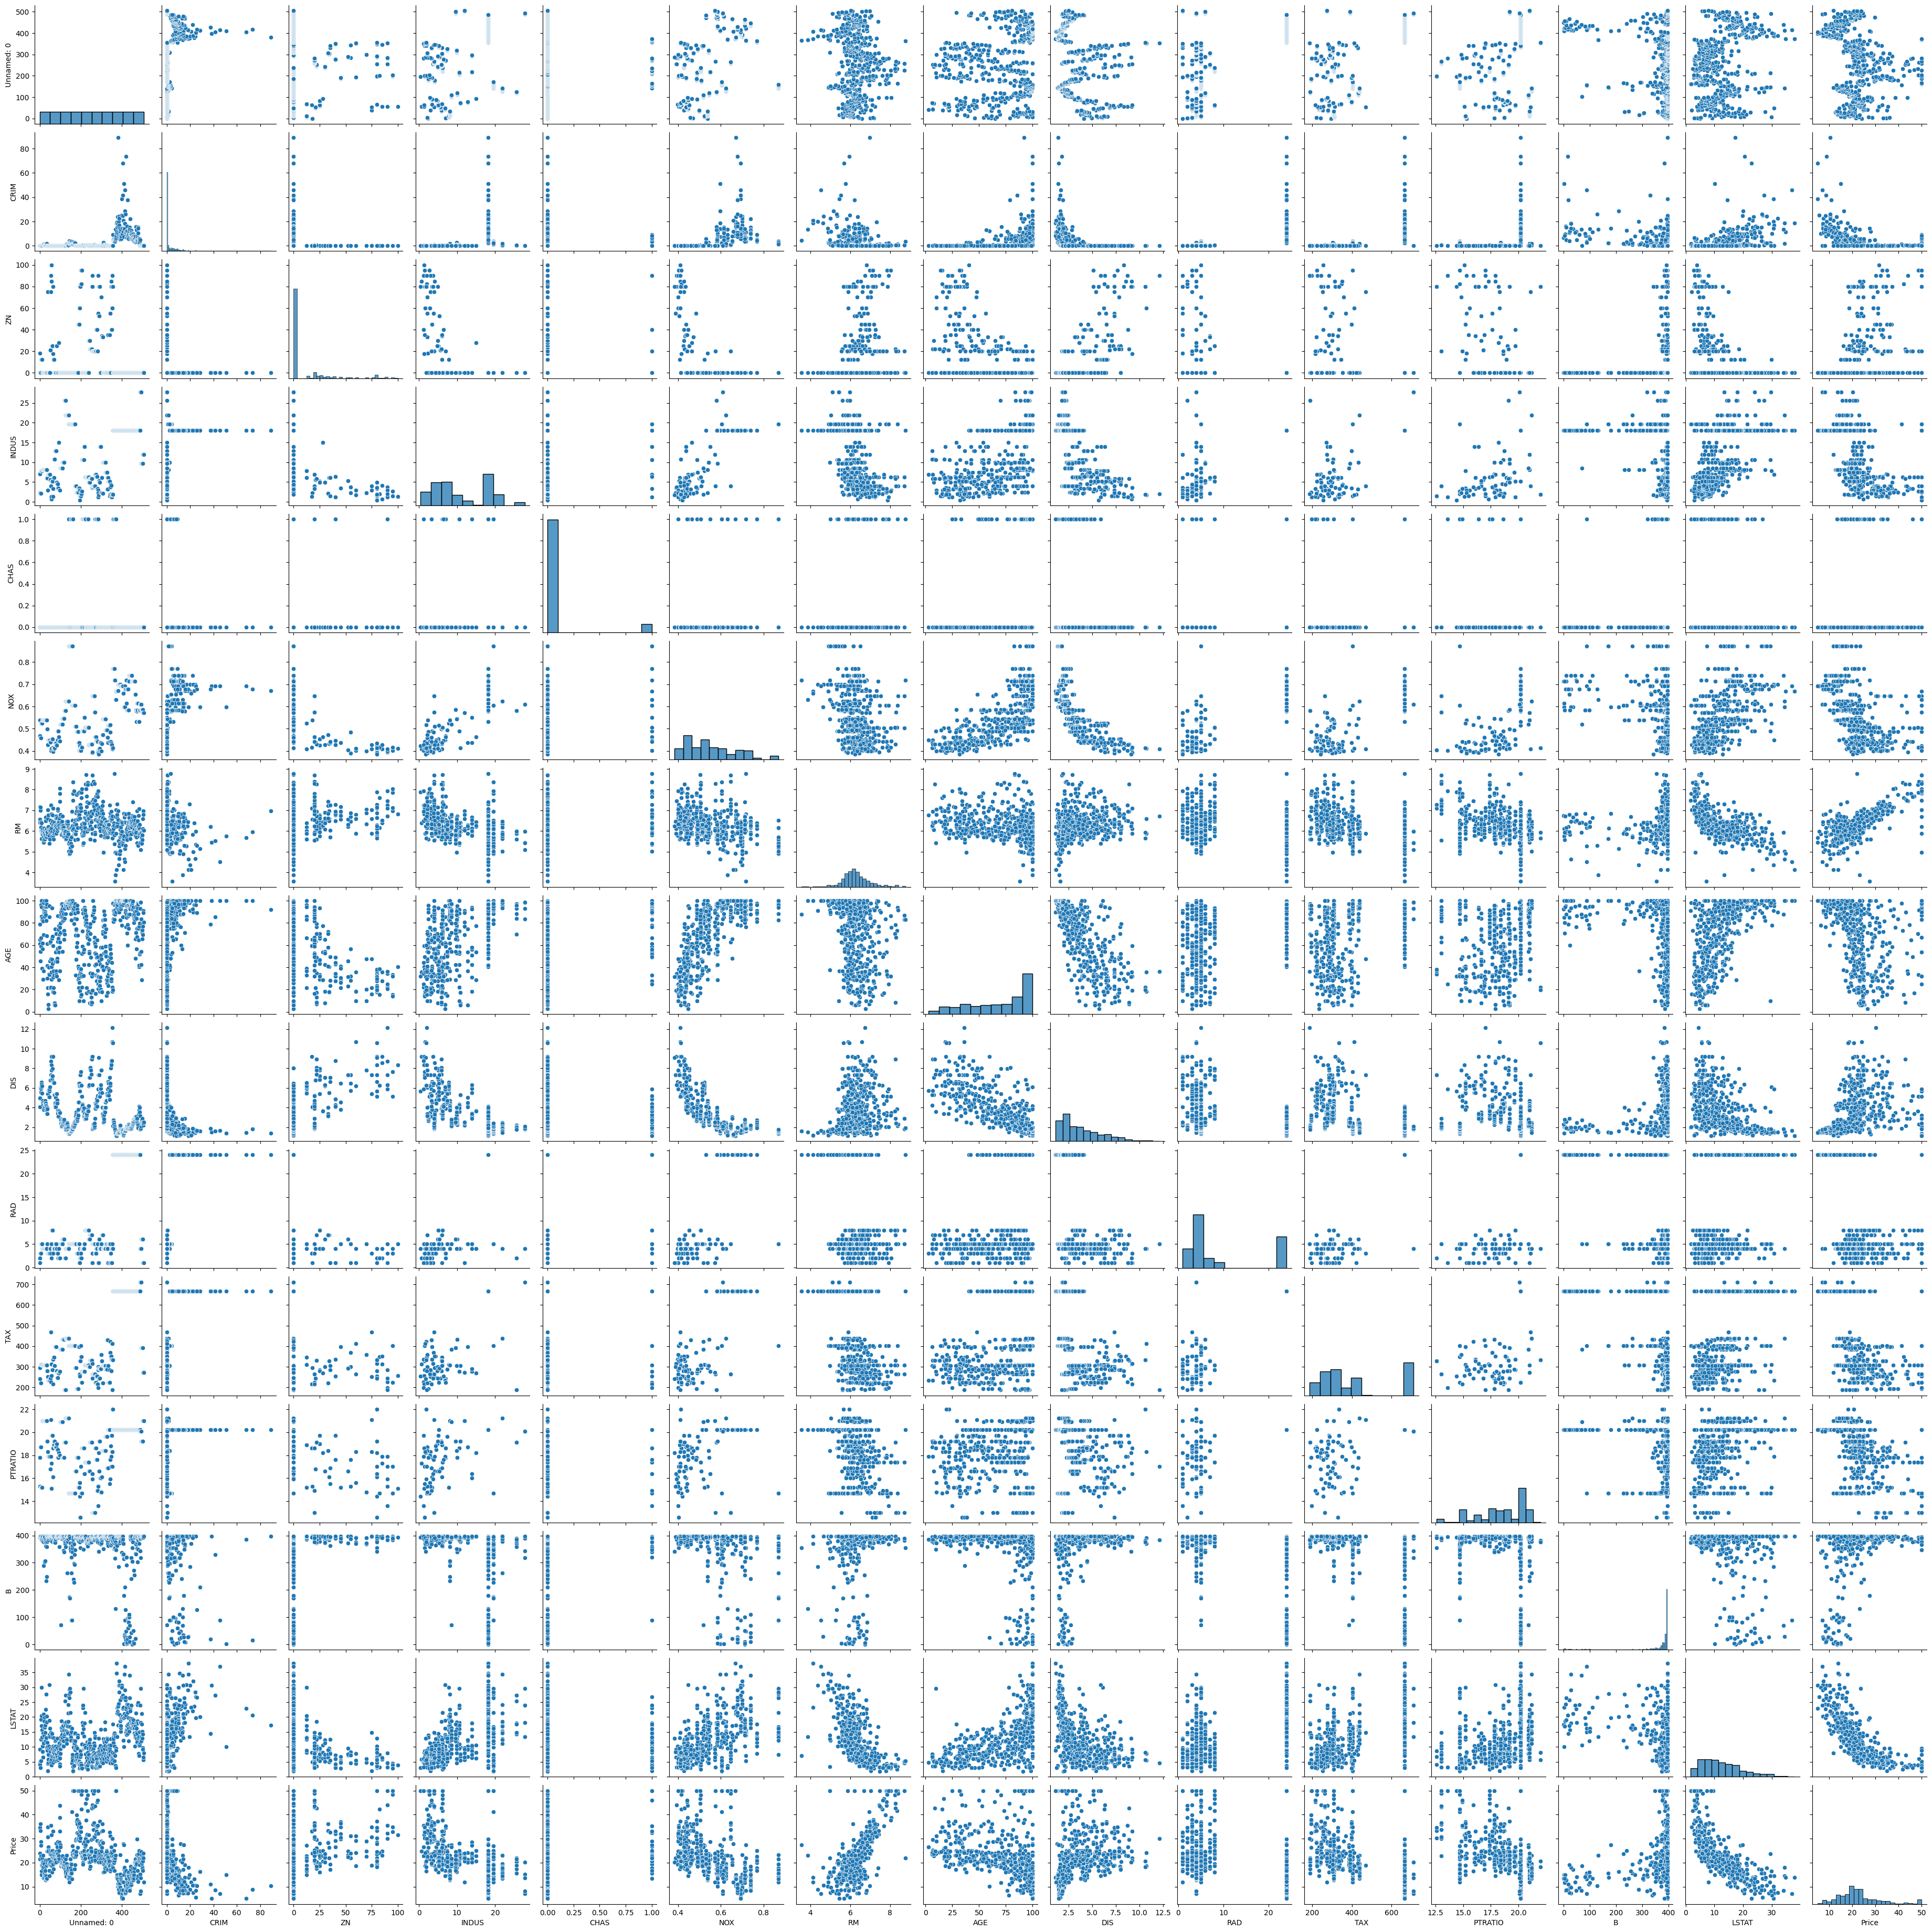

In [16]:
import seaborn as sns
sns.pairplot(boston)

Text(0, 0.5, 'Price')

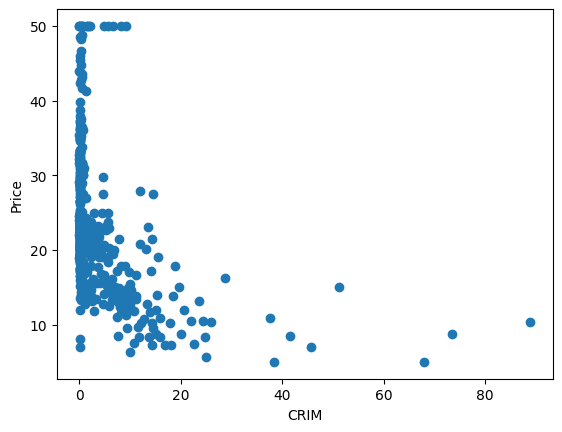

In [17]:
plt.scatter(boston['CRIM'],boston['Price'])
plt.xlabel('CRIM')
plt.ylabel('Price')

In [18]:
X=boston.iloc[:,:-1]
y=boston.iloc[:,-1]

In [19]:
X.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [20]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [23]:
X_train

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21
116,116,0.13158,0.0,10.01,0.0,0.547,6.176,72.5,2.7301,6.0,432.0,17.8,393.30,12.04
45,45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3.0,233.0,17.9,396.90,10.21
16,16,1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4.0,307.0,21.0,386.85,6.58
468,468,15.57570,0.0,18.10,0.0,0.580,5.926,71.0,2.9084,24.0,666.0,20.2,368.74,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,106,0.17120,0.0,8.56,0.0,0.520,5.836,91.9,2.2110,5.0,384.0,20.9,395.67,18.66
270,270,0.29916,20.0,6.96,0.0,0.464,5.856,42.1,4.4290,3.0,223.0,18.6,388.65,13.00
348,348,0.01501,80.0,2.01,0.0,0.435,6.635,29.7,8.3440,4.0,280.0,17.0,390.94,5.99
435,435,11.16040,0.0,18.10,0.0,0.740,6.629,94.6,2.1247,24.0,666.0,20.2,109.85,23.27


In [24]:
X_test

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,173,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04
274,274,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53
491,491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07
72,72,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
452,452,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,441,9.72418,0.0,18.10,0.0,0.740,6.406,97.2,2.0651,24.0,666.0,20.2,385.96,19.52
23,23,0.98843,0.0,8.14,0.0,0.538,5.813,100.0,4.0952,4.0,307.0,21.0,394.54,19.88
225,225,0.52693,0.0,6.20,0.0,0.504,8.725,83.0,2.8944,8.0,307.0,17.4,382.00,4.63
433,433,5.58107,0.0,18.10,0.0,0.713,6.436,87.9,2.3158,24.0,666.0,20.2,100.19,16.22


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [26]:
X_train

array([[-1.75344289, -0.41425879, -0.50512499, ...,  0.18727079,
         0.39651419, -1.01531611],
       [-0.96602578, -0.40200818, -0.50512499, ..., -0.21208981,
         0.3870674 , -0.05366252],
       [-1.46968898, -0.39721053, -0.50512499, ..., -0.16771641,
         0.42854113, -0.31132373],
       ...,
       [ 0.67974693, -0.41604586,  3.03838247, ..., -0.56707702,
         0.35987906, -0.90549329],
       [ 1.2969117 ,  0.92611293, -0.50512499, ...,  0.8528718 ,
        -2.87841346,  1.52750437],
       [-1.06533965, -0.39030549, -0.50512499, ...,  1.16348561,
        -3.32828832, -0.25218837]])

In [27]:
X_test

array([[-0.56167645, -0.406801  , -0.50512499, ..., -0.74457062,
         0.41241246, -0.47605794],
       [ 0.15480219, -0.41105674,  1.26662874, ..., -0.30083661,
         0.42854113, -1.25185755],
       [ 1.69416718, -0.4051199 , -0.50512499, ...,  0.8084984 ,
         0.35031705,  0.79535229],
       ...,
       [-0.19279636, -0.35439903, -0.50512499, ..., -0.38958342,
         0.25688594, -1.09697922],
       [ 1.282724  ,  0.25423453, -0.50512499, ...,  0.8528718 ,
        -2.98970133,  0.53487511],
       [ 1.38203787,  0.77732457, -0.50512499, ...,  0.8528718 ,
         0.33199949,  0.56585078]])

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
regression = LinearRegression()

In [30]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
print(regression.coef_)

[-0.66785814 -1.11544136  0.91101106  0.37603716  0.80408864 -1.7548917
  2.95102772 -0.43884827 -3.02131767  2.43016199 -1.27662638 -2.03215882
  1.03101996 -3.92790503]


In [32]:
print(regression.intercept_)

23.01581920903955


In [33]:
#on which Intercept model is trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [34]:
regr_pred = regression.predict(X_test)

In [35]:
regr_pred

array([28.61693942, 36.30028466, 14.31747783, 26.13015646, 18.70581899,
       23.68237448, 16.58103592, 14.36386779, 22.7332411 , 19.20858225,
       24.4446439 , 19.13298699, -7.12592238, 22.39404487, 18.42961061,
       26.09090302, 20.28586961,  5.5908678 , 40.7897148 , 17.40193287,
       27.18239724, 29.96110704, 11.39733239, 22.44295669, 18.0639387 ,
       15.55736931, 23.82078096, 14.36349234, 21.91394005, 17.96983389,
       22.04084013, 24.59565913, 25.58555609, 18.79344782, 16.29084585,
       17.74089966, 31.66546188, 19.41626474, 23.66656996, 25.59616199,
       12.51566039, 31.3847964 , 42.9440455 , 18.17964226, 27.31307527,
       17.2894997 , 14.28493643, 26.85656515, 20.04672805, 30.86519764,
       21.95797082, 33.77491134, 16.16898485, 26.65939373, 39.12330782,
       22.8226728 , 18.83790583, 32.98235227, 25.20814878, 12.53346677,
       23.42327431, 31.78485242, 31.80839407, 17.16507905, 20.48956949,
       16.05460922, 20.47257935, 26.77739296, 32.11914138, 11.77

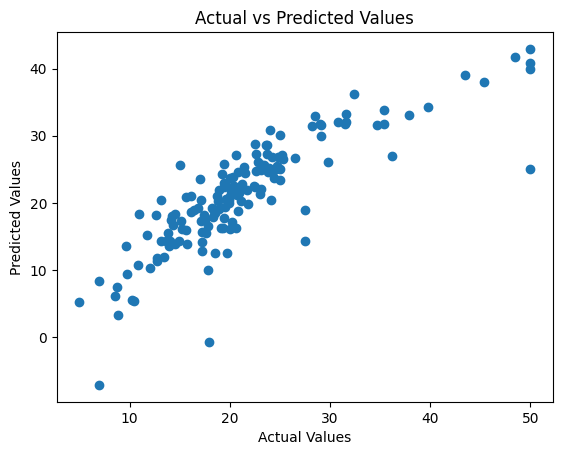

In [36]:
#lets Plot the predicted values and actual values
import matplotlib.pyplot as plt
plt.scatter(y_test, regr_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [37]:
Residuals = y_test - regr_pred


In [38]:
Residuals

173    -5.016939
274    -3.900285
491    -0.717478
72     -3.330156
452    -2.605819
         ...    
441    -0.188631
23      0.624582
225    10.011202
433    -2.334260
447    -5.550541
Name: Price, Length: 152, dtype: float64

C:\Users\MinakshiKhirade\AppData\Local\Temp\ipykernel_960\2719317996.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Residuals, bins=20)


<Axes: xlabel='Price', ylabel='Density'>

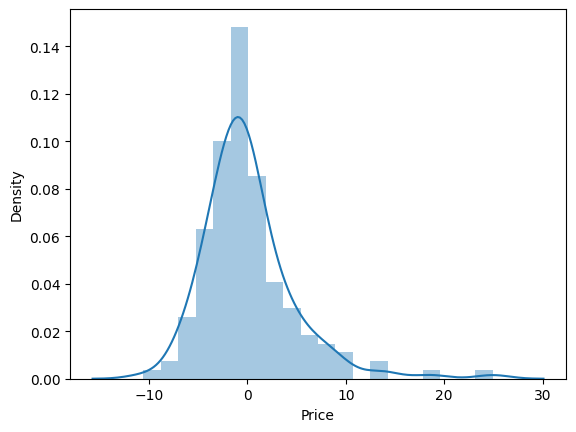

In [39]:
sns.distplot(Residuals, bins=20)

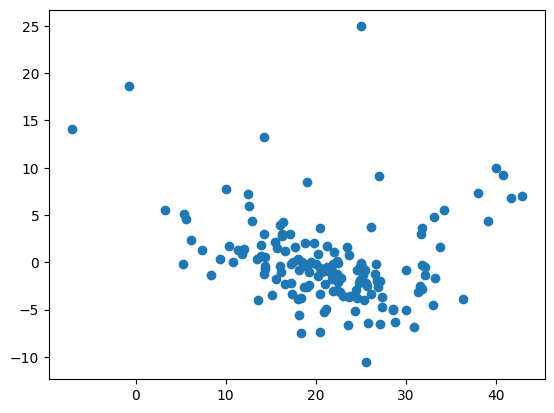

In [40]:
##scatter plot of residuals vs predicted values
plt.scatter(regr_pred, Residuals)

In [41]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [42]:
print("Mean Absolute Error:", mean_absolute_error(y_test, regr_pred))
print("Mean Squared Error:", mean_squared_error(y_test, regr_pred))

Mean Absolute Error: 3.2116643377514236
Mean Squared Error: 21.969368008053962


In [43]:
#r2_score(y_test, regr_pred)
print("R2 Score:", r2_score(y_test, regr_pred))

R2 Score: 0.7051609808903441


In [44]:
#adjusted r2 score
n = X_test.shape[0] # number of samples
p = X_test.shape[1] # number of features
adjusted_r2 = 1 - (1 - r2_score(y_test, regr_pred)) * (n - 1) / (n - p - 1)
print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 0.6750314460908172


In [45]:
import pickle

In [46]:
pickle.dump(regression, open('regmodel.pkl', 'wb'))

In [47]:
pickled_model = pickle.load(open('regmodel.pkl', 'rb'))